/tmp/ipykernel_22783/3163518722.py:9: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  df_reg = df_reg.append(df_reg_affine)


Text(0.5, 1.0, 'Dice Multi Atlas Registration with K nearest images')

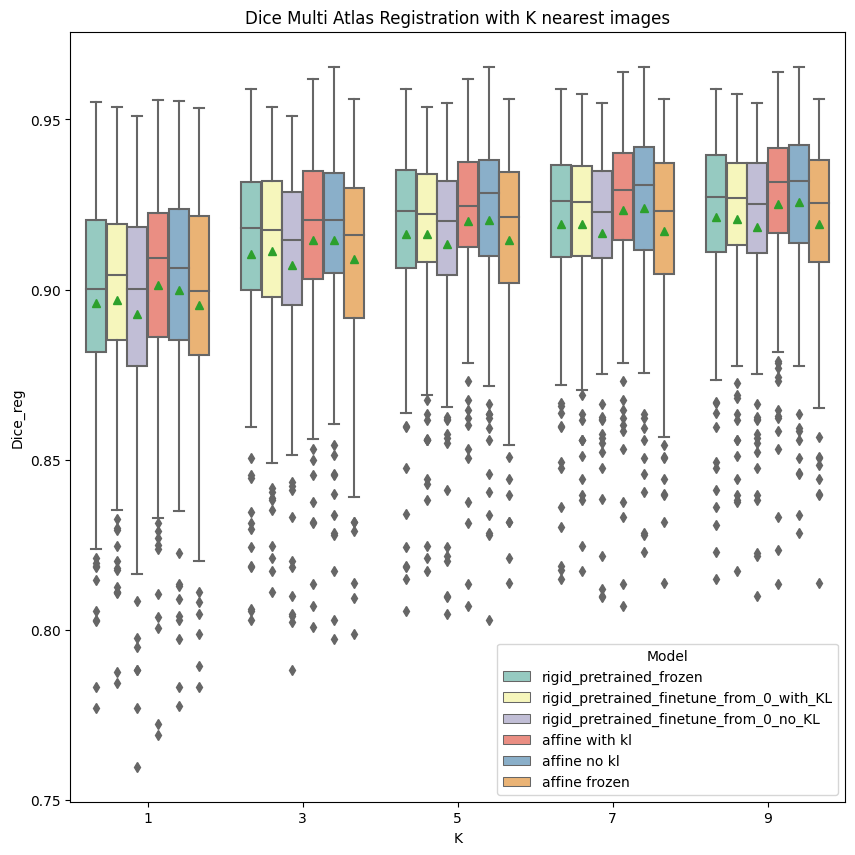

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

df_reg = pd.read_csv('df_reg_rigid.csv')
df_reg['Model'] = 'rigid_'+df_reg['Model']
df_reg_affine = pd.read_csv('df_reg_affine.csv')

df_reg = df_reg.append(df_reg_affine)
df_sel = pd.read_csv('df_sel.csv')

plt.figure(figsize=(10, 10))
sns.boxplot(x="K", y="Dice_reg", hue="Model", data=df_reg, palette="Set3", showmeans=True)
plt.title('Dice Multi Atlas Registration with K nearest images')

#plt.figure(figsize=(10, 10))
#sns.boxplot(x="K", y="Dice_base", data=df_sel, palette="Set3")
#plt.title('Baseline Dice of using only K nearest without registration')

In [2]:
# Get the mean dice of each model at each K
print(df_reg_affine.groupby(['K', 'Model'])['Dice_reg'].mean())

K  Model         
1  affine frozen     0.895394
   affine no kl      0.899770
   affine with kl    0.901277
3  affine frozen     0.909002
   affine no kl      0.914655
   affine with kl    0.914693
5  affine frozen     0.914553
   affine no kl      0.920516
   affine with kl    0.920284
7  affine frozen     0.917288
   affine no kl      0.923985
   affine with kl    0.923338
9  affine frozen     0.919305
   affine no kl      0.925756
   affine with kl    0.925165
Name: Dice_reg, dtype: float64


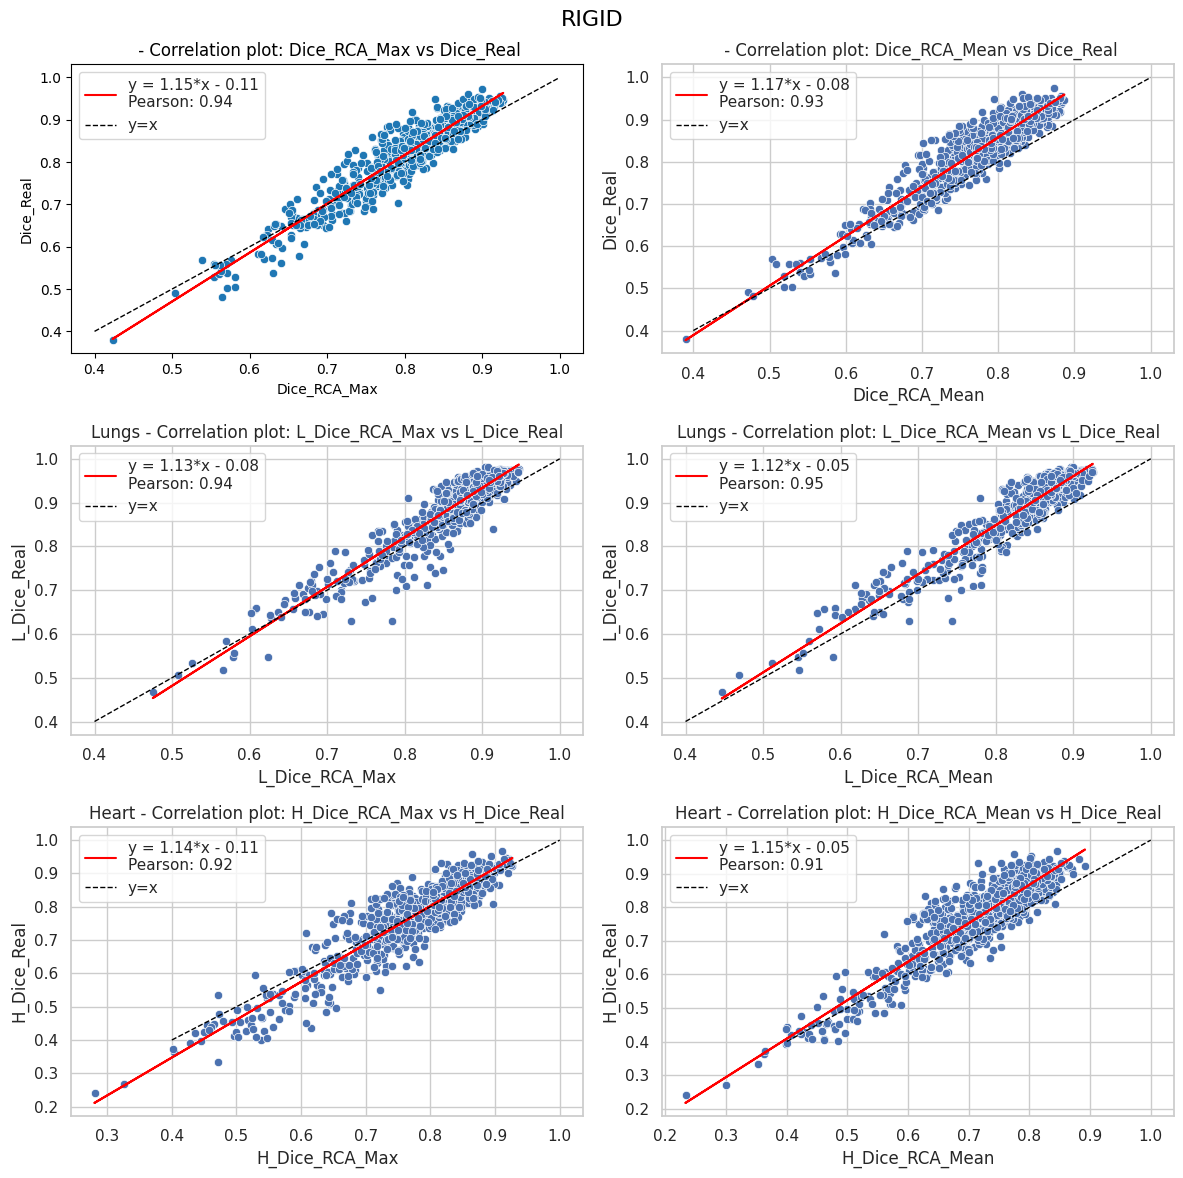

In [3]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import linregress, pearsonr


# Define a function to create a correlation plot
def create_corr_plot(y_col, x_col, data, title):
    sns.set(style='whitegrid')
    #plt.figure(figsize=(8, 6))
    
    # Perform linear regression
    slope, intercept, r_value, _, _ = linregress(data[x_col], data[y_col])

    # Calculate Pearson coefficient
    pearson_coeff, _ = pearsonr(data[x_col], data[y_col])

    # Create a scatter plot
    sns.scatterplot(x=x_col, y=y_col, data=data)

    # Plot the fitted line
    x = data[x_col]
    y = slope * x + intercept
    
    if intercept > 0:
        plt.plot(x, y, color='red', label=f'y = {slope:.2f}*x + {intercept:.2f}\nPearson: {pearson_coeff:.2f}')
    else:
        plt.plot(x, y, color='red', label=f'y = {slope:.2f}*x - {abs(intercept):.2f}\nPearson: {pearson_coeff:.2f}')
        
    # Draw [0,0], [1,1] lines
    plt.plot([0.4, 1], [0.4, 1], color='black', linestyle='--', linewidth=1, label='y=x')
    
    # Customize plot
    plt.title(f'{title} - Correlation plot: {x_col} vs {y_col}')
    plt.legend()


# Load the data
df_rca = pd.read_csv('df_rca_rigid_lh.csv')

# Create correlation plots
plt.figure(figsize=(12, 12), dpi = 100)
plt.suptitle('RIGID', fontsize=16)
plt.subplot(3,2,1)
create_corr_plot("Dice_Real", "Dice_RCA_Max", df_rca, '')
plt.subplot(3,2,2)
create_corr_plot("Dice_Real", "Dice_RCA_Mean", df_rca, '')
plt.subplot(3,2,3)
create_corr_plot("L_Dice_Real", "L_Dice_RCA_Max", df_rca, 'Lungs')
plt.subplot(3,2,4)
create_corr_plot("L_Dice_Real", "L_Dice_RCA_Mean", df_rca, 'Lungs')
plt.subplot(3,2,5)
create_corr_plot("H_Dice_Real", "H_Dice_RCA_Max", df_rca, 'Heart')
plt.subplot(3,2,6)
create_corr_plot("H_Dice_Real", "H_Dice_RCA_Mean", df_rca, 'Heart')

plt.tight_layout()
plt.show()

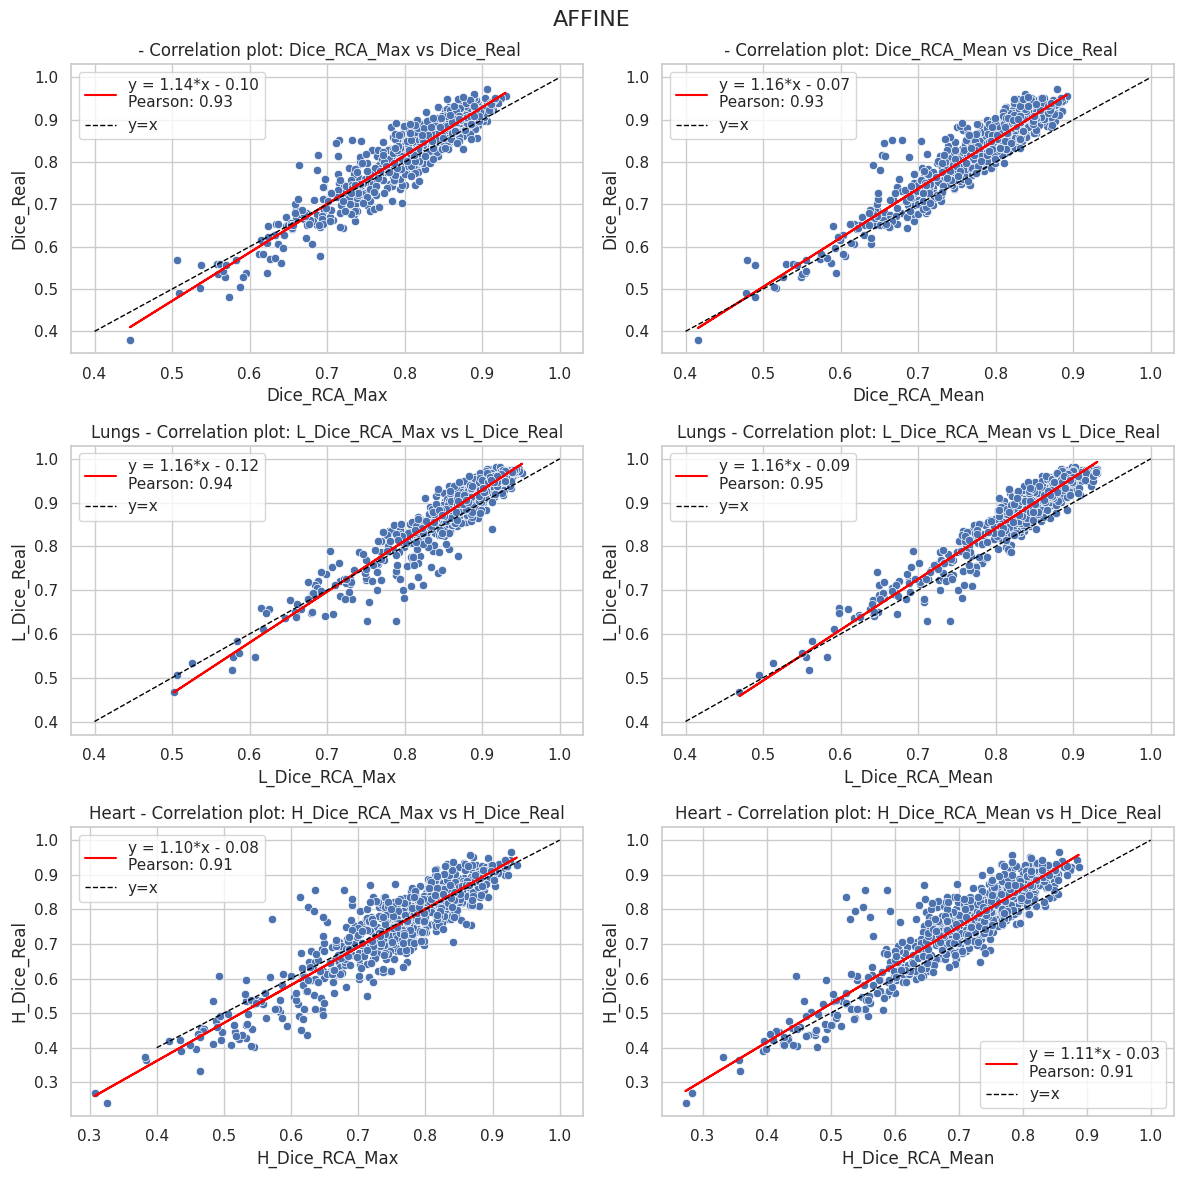

In [4]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import linregress, pearsonr


# Define a function to create a correlation plot
def create_corr_plot(y_col, x_col, data, title):
    sns.set(style='whitegrid')
    #plt.figure(figsize=(8, 6))
    
    # Perform linear regression
    slope, intercept, r_value, _, _ = linregress(data[x_col], data[y_col])

    # Calculate Pearson coefficient
    pearson_coeff, _ = pearsonr(data[x_col], data[y_col])

    # Create a scatter plot
    sns.scatterplot(x=x_col, y=y_col, data=data)

    # Plot the fitted line
    x = data[x_col]
    y = slope * x + intercept
    
    if intercept > 0:
        plt.plot(x, y, color='red', label=f'y = {slope:.2f}*x + {intercept:.2f}\nPearson: {pearson_coeff:.2f}')
    else:
        plt.plot(x, y, color='red', label=f'y = {slope:.2f}*x - {abs(intercept):.2f}\nPearson: {pearson_coeff:.2f}')
        
    # Draw [0,0], [1,1] lines
    plt.plot([0.4, 1], [0.4, 1], color='black', linestyle='--', linewidth=1, label='y=x')
    
    # Customize plot
    plt.title(f'{title} - Correlation plot: {x_col} vs {y_col}')
    plt.legend()


# Load the data
df_rca = pd.read_csv('df_rca_affine_lh.csv')

# Create correlation plots
plt.figure(figsize=(12, 12), dpi = 100)
plt.suptitle('AFFINE', fontsize=16)
plt.subplot(3,2,1)
create_corr_plot("Dice_Real", "Dice_RCA_Max", df_rca, '')
plt.subplot(3,2,2)
create_corr_plot("Dice_Real", "Dice_RCA_Mean", df_rca, '')
plt.subplot(3,2,3)
create_corr_plot("L_Dice_Real", "L_Dice_RCA_Max", df_rca, 'Lungs')
plt.subplot(3,2,4)
create_corr_plot("L_Dice_Real", "L_Dice_RCA_Mean", df_rca, 'Lungs')
plt.subplot(3,2,5)
create_corr_plot("H_Dice_Real", "H_Dice_RCA_Max", df_rca, 'Heart')
plt.subplot(3,2,6)
create_corr_plot("H_Dice_Real", "H_Dice_RCA_Mean", df_rca, 'Heart')

plt.tight_layout()
plt.show()


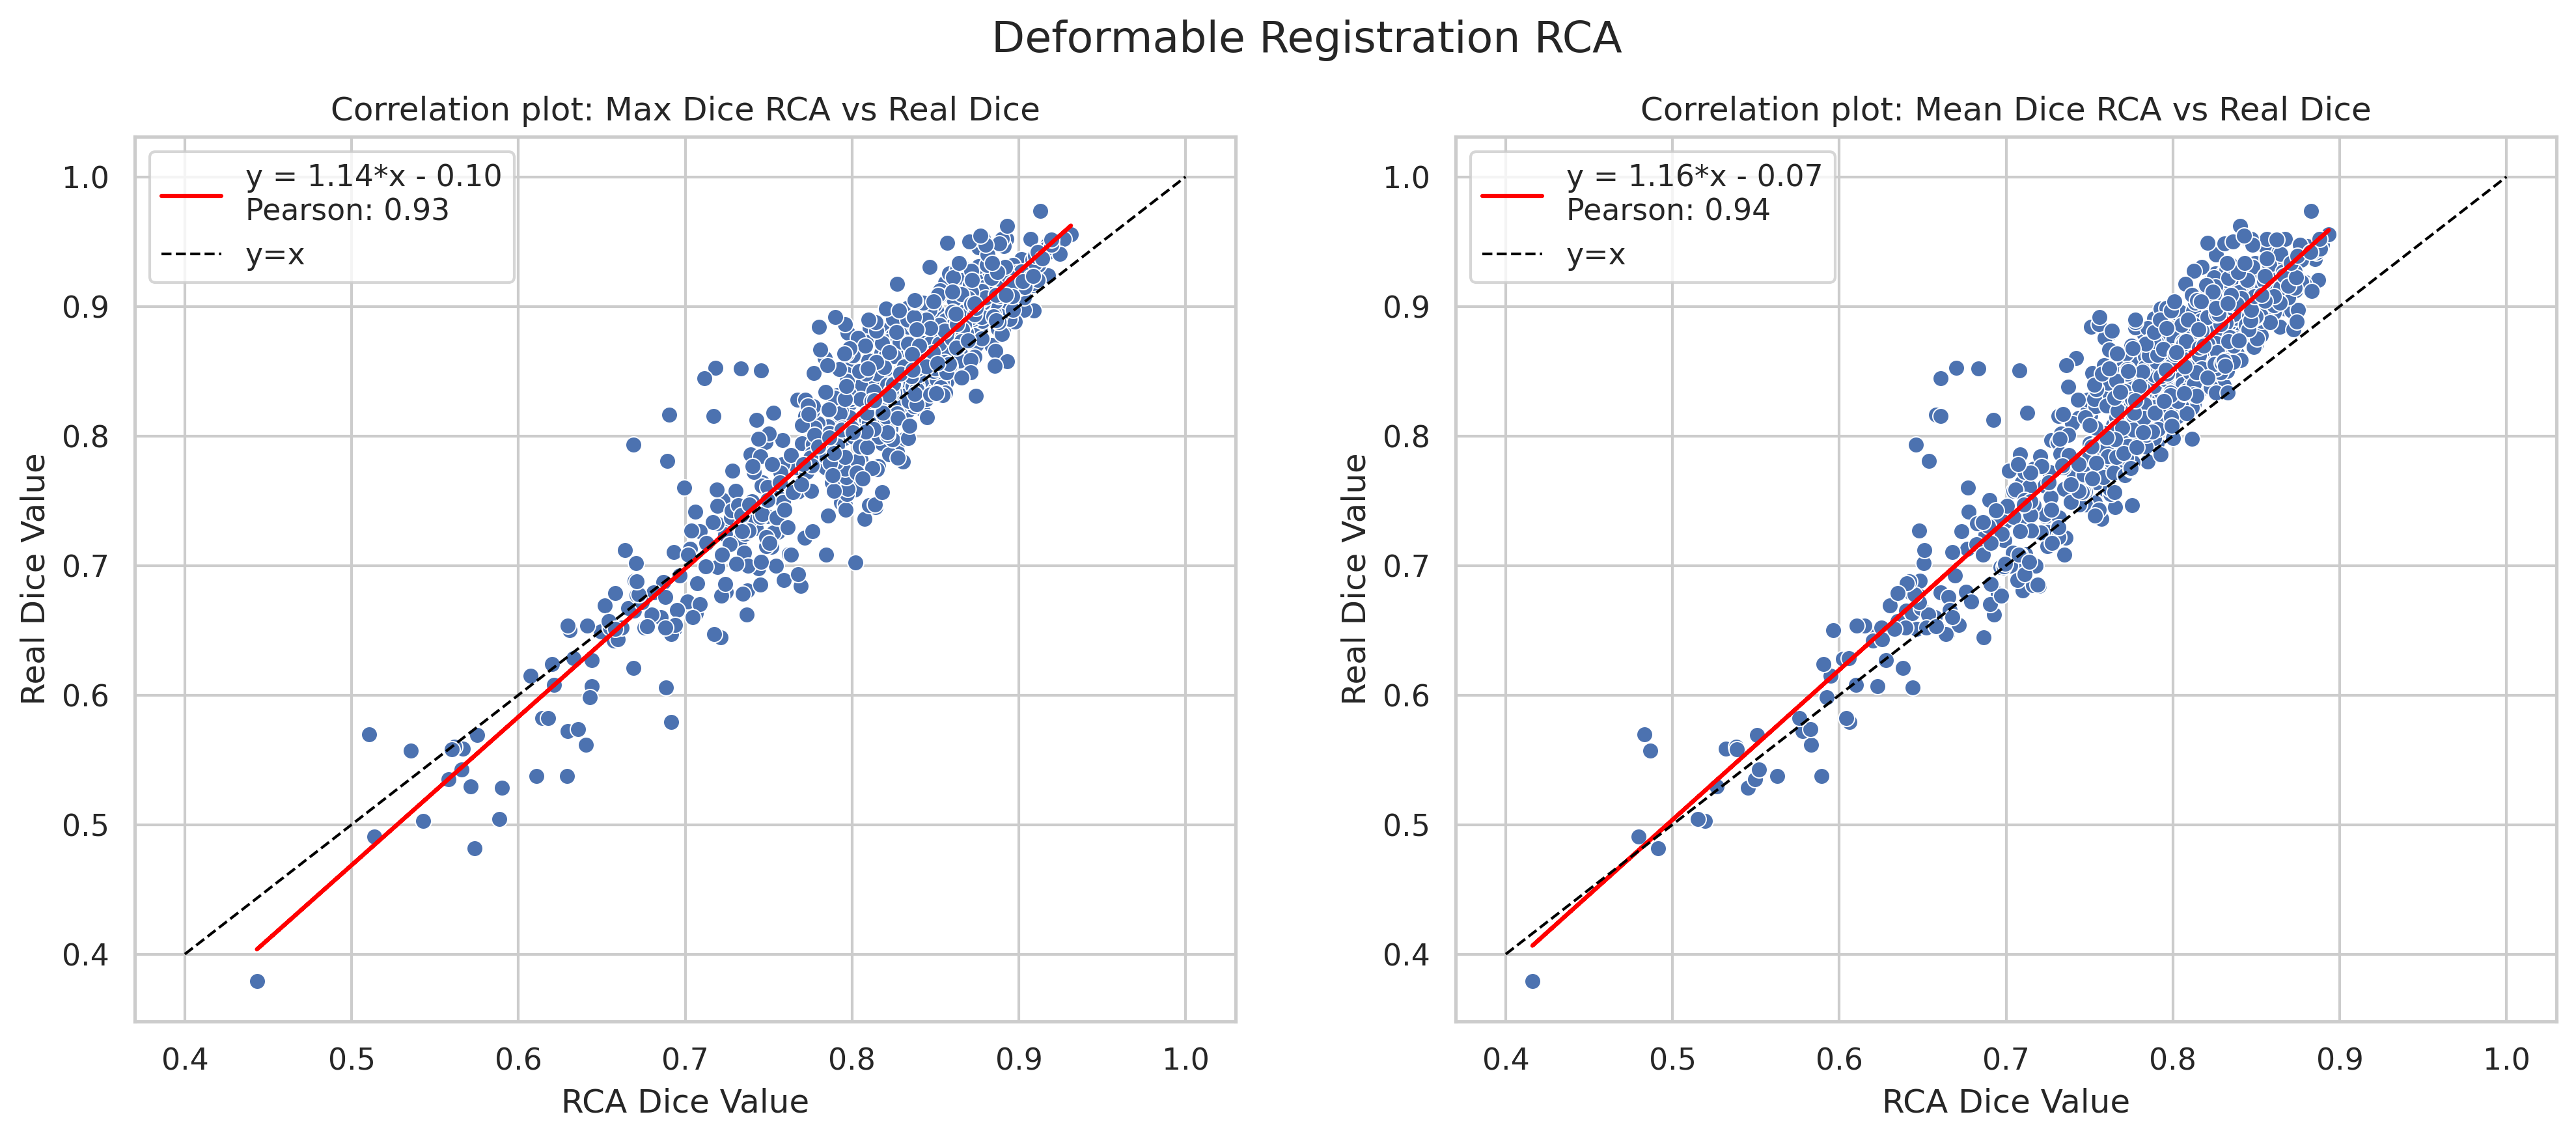

In [7]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import linregress, pearsonr

# Define a function to create a correlation plot
def create_corr_plot(y_col, x_col, data, x_name, y_name):
    sns.set(style='whitegrid')
    #plt.figure(figsize=(8, 6))
    
    # Perform linear regression
    slope, intercept, r_value, _, _ = linregress(data[x_col], data[y_col])

    # Calculate Pearson coefficient
    pearson_coeff, _ = pearsonr(data[x_col], data[y_col])

    # Create a scatter plot
    sns.scatterplot(x=x_col, y=y_col, data=data)

    # Plot the fitted line
    x = data[x_col]
    y = slope * x + intercept
    
    if intercept > 0:
        plt.plot(x, y, color='red', label=f'y = {slope:.2f}*x + {intercept:.2f}\nPearson: {pearson_coeff:.2f}')
    else:
        plt.plot(x, y, color='red', label=f'y = {slope:.2f}*x - {abs(intercept):.2f}\nPearson: {pearson_coeff:.2f}')
        
    # Draw [0,0], [1,1] lines
    plt.plot([0.4, 1], [0.4, 1], color='black', linestyle='--', linewidth=1, label='y=x')
    
    plt.xlabel('RCA Dice Value')
    plt.ylabel('Real Dice Value')
    
    # Customize plot
    plt.title(f'Correlation plot: {x_name} vs {y_name}')
    plt.legend()
    

# Load the data
df_rca_deformable = pd.read_csv('df_rca_affine_deformable_lh.csv')

# Create correlation plots
plt.figure(figsize=(16, 6), dpi = 300)
plt.suptitle('Deformable Registration RCA', fontsize=16)
plt.subplot(1,2,1)
create_corr_plot("Dice_Real", "Dice_RCA_Max", df_rca_deformable, 'Max Dice RCA', 'Real Dice')
plt.subplot(1,2,2)
create_corr_plot("Dice_Real", "Dice_RCA_Mean", df_rca_deformable, 'Mean Dice RCA', 'Real Dice')

plt.savefig('Correlation plots.png', dpi=300, bbox_inches='tight')

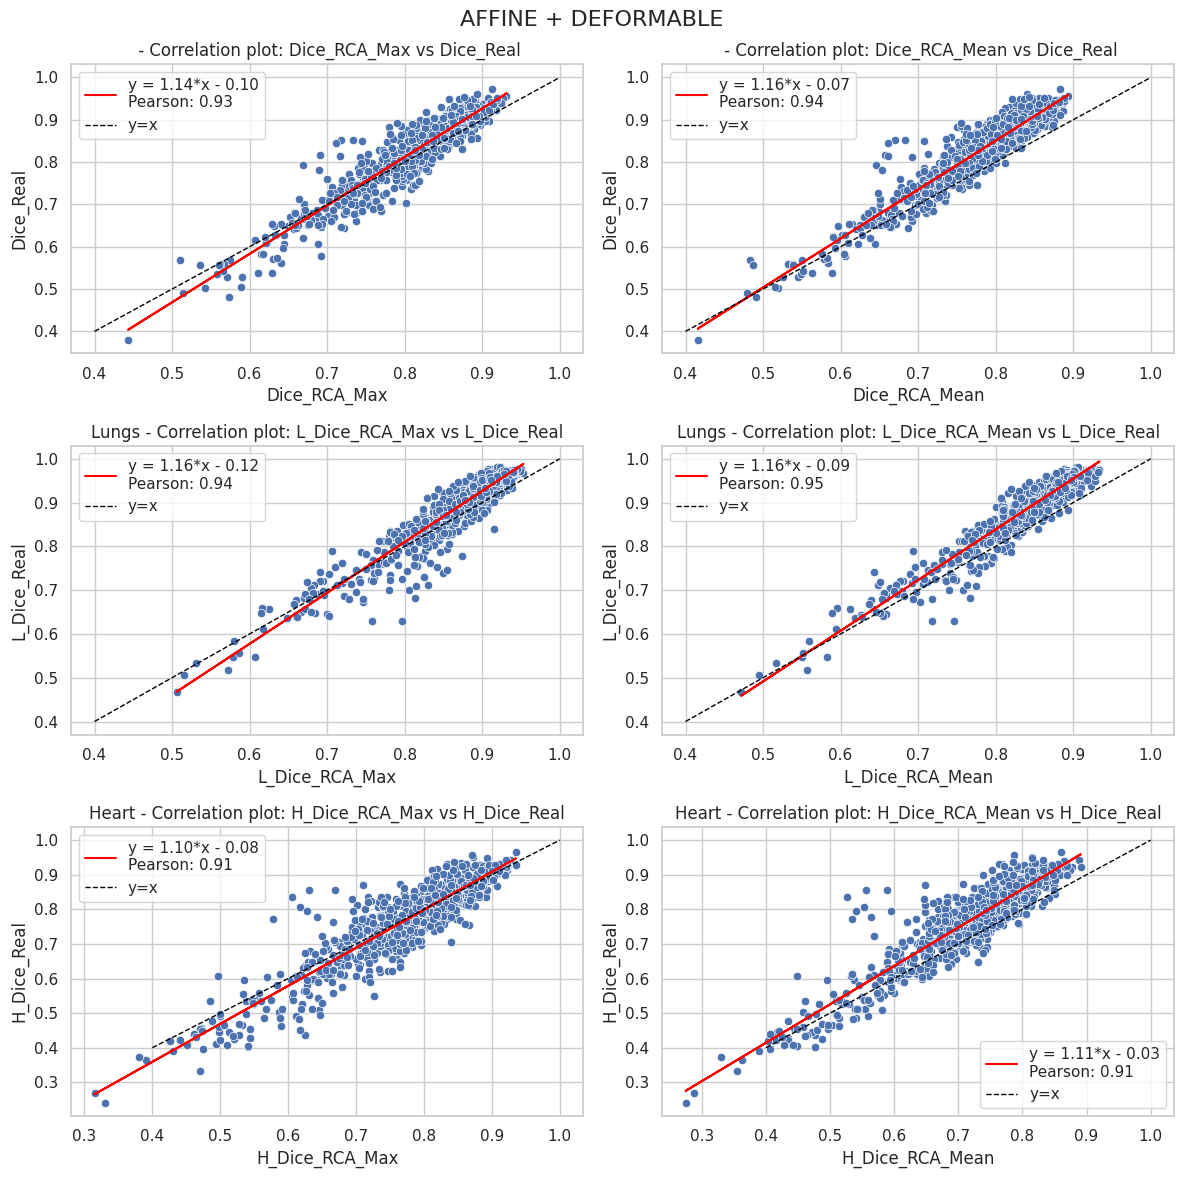

In [5]:
# Load the data
df_rca_deformable = pd.read_csv('df_rca_affine_deformable_lh.csv')

# Create correlation plots
plt.figure(figsize=(12, 12), dpi = 100)
plt.suptitle('Deformable registration for RCA evaluation', fontsize=16)
plt.subplot(3,2,1)
create_corr_plot("Dice_Real", "Dice_RCA_Max", df_rca_deformable, '')
plt.subplot(3,2,2)
create_corr_plot("Dice_Real", "Dice_RCA_Mean", df_rca_deformable, '')
plt.subplot(3,2,3)
create_corr_plot("L_Dice_Real", "L_Dice_RCA_Max", df_rca_deformable, 'Lungs')
plt.subplot(3,2,4)
create_corr_plot("L_Dice_Real", "L_Dice_RCA_Mean", df_rca_deformable, 'Lungs')
plt.subplot(3,2,5)
create_corr_plot("H_Dice_Real", "H_Dice_RCA_Max", df_rca_deformable, 'Heart')
plt.subplot(3,2,6)
create_corr_plot("H_Dice_Real", "H_Dice_RCA_Mean", df_rca_deformable, 'Heart')

plt.tight_layout()
plt.show()